## Notebook with analysis pertaining to Figure 3 and S3
Does not include the pathogen mimicry analysis, see "notebook_pathogen_mimicry.ipynb" for this analysis. Also contains the code to export data for Supplemental Table 10.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats

pd.options.mode.copy_on_write = True

plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
sns.set_palette("colorblind")
global_fontsize = 12
global_color = 'tab:grey'

In [2]:
pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")
pdb_clusters["chain_id_0"] = pdb_clusters["chain_id_0"].fillna("NA")
pdb_clusters["chain_id_1"] = pdb_clusters["chain_id_1"].fillna("NA")

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_1599/2822720730.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")


In [3]:
cluster_summary = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_cluster_summary.tsv", sep="\t")
noisy_cluster_ids = list(set(cluster_summary[cluster_summary["cluster_qtm"] < 0.5].index))
print(len(noisy_cluster_ids))

363


In [4]:
cluster_lca = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/cluster_lca.tsv", sep="\t", header=None)
cluster_lca.columns = ["rep","lca_id","lca_level","lca_name"]

## Identify CATH-diverse clusters

In [5]:
pdb_clusters.loc[pdb_clusters['cath_is_pair'] != 1, "cath_annot"] = np.nan

dimer_cluster_purity = pdb_clusters.groupby('dimercluster')['cath_annot'].describe()
int_cluster_purity = pdb_clusters.groupby('intcluster')['cath_annot'].describe()

In [6]:
## Count number of clusters in each category

## Exclude singleton clusters
cluster_size = pdb_clusters.groupby("intcluster")["pdb_id"].count()
singleton_ids = list(set(cluster_size[cluster_size == 1].index))
pdb_clusters_nonsingle = pdb_clusters[~pdb_clusters["intcluster"].isin(singleton_ids)]
print("Number of non-singleton interface clusters: ", pdb_clusters_nonsingle["intcluster"].nunique())

## Find number of clusters which are peptide-peptide or protein-peptide (not possible to have CATH annotation)
protpep_status_grouped = pdb_clusters_nonsingle.groupby("intcluster")["protpep_status"].describe()
prot_prot_cluster_ids = list(set(protpep_status_grouped[protpep_status_grouped["top"] == "Protein-protein"].index))
print("Number of clusters with majority protein-peptide or peptide-peptide: ", protpep_status_grouped[((protpep_status_grouped["top"] == "Protein-peptide") | (protpep_status_grouped["top"] == "Peptide-peptide"))].shape[0])

## Exclude noisy alignments
print("Number of clusters with noisy alignments: ", len([x for x in noisy_cluster_ids if x in prot_prot_cluster_ids]))
prot_prot_cluster_ids = [x for x in prot_prot_cluster_ids if x not in noisy_cluster_ids]
print("Sanity check - number of protein-protein clusters: ", len(prot_prot_cluster_ids))

## Find number of clusters with no CATH annotation
pdb_clusters_prot_prot = pdb_clusters_nonsingle[pdb_clusters_nonsingle["intcluster"].isin(prot_prot_cluster_ids)]
no_cath_clusters = list(set(int_cluster_purity[int_cluster_purity["unique"] == 0].index))
no_cath_clusters_filtered = [x for x in no_cath_clusters if x in prot_prot_cluster_ids]
print("Number of protein-protein clusters with no CATH annotations: ", len(no_cath_clusters_filtered))

## Find number of clusters with only one interface with CATH annotation
only_one_cath_clusters = list(set(int_cluster_purity[int_cluster_purity["count"] == 1].index))
only_one_cath_clusters_filtered = [x for x in only_one_cath_clusters if x in prot_prot_cluster_ids]
print("Number of protein-protein clusters with only one interface with CATH annotation: ", len(only_one_cath_clusters_filtered))

## Find number of clusters with more than one CATH annotation but all are same
all_same_cath_clusters = list(set(int_cluster_purity[((int_cluster_purity["count"] > 1) & (int_cluster_purity["unique"] == 1))].index))
all_same_cath_clusters_filtered = [x for x in all_same_cath_clusters if x in prot_prot_cluster_ids]
print("Number of protein-protein clusters with more than one CATH annotation, all are the same: ", len(all_same_cath_clusters_filtered))

## Find number of clusters with more than one unique CATH annotation
diverse_cath_clusters = list(set(int_cluster_purity[((int_cluster_purity["count"] > 1) & (int_cluster_purity["unique"] > 1))].index))
diverse_cath_clusters_filtered = [x for x in diverse_cath_clusters if x in prot_prot_cluster_ids]
print("Number of protein-protein clusters with more than one unique CATH annotation: ", len(diverse_cath_clusters_filtered))

Number of non-singleton interface clusters:  54150
Number of clusters with majority protein-peptide or peptide-peptide:  2044
Number of clusters with noisy alignments:  351
Sanity check - number of protein-protein clusters:  51755
Number of protein-protein clusters with no CATH annotations:  37026
Number of protein-protein clusters with only one interface with CATH annotation:  1004
Number of protein-protein clusters with more than one CATH annotation, all are the same:  13004
Number of protein-protein clusters with more than one unique CATH annotation:  721


In [7]:
combined_clusters = pdb_clusters[pdb_clusters['intcluster'].isin(diverse_cath_clusters_filtered)]
combined_clusters.dropna(subset=["cath_annot"], axis=0, inplace=True)
combined_clusters["class_0"] = [x.split(".")[0] for x in combined_clusters["cath_annot"]]
combined_clusters["class_1"] = [x.split("-")[1].split(".")[0] for x in combined_clusters["cath_annot"]]
combined_clusters["arch_0"] = [".".join(x.split(".")[0:2]) for x in combined_clusters["cath_annot"]]
combined_clusters["arch_1"] = [".".join(x.split("-")[1].split(".")[0:2]) for x in combined_clusters["cath_annot"]]
combined_clusters["topo_0"] = [".".join(x.split(".")[0:3]) for x in combined_clusters["cath_annot"]]
combined_clusters["topo_1"] = [".".join(x.split("-")[1].split(".")[0:3]) for x in combined_clusters["cath_annot"]]
combined_clusters["homol_0"] = [".".join(x.split("-")[0].split(".")[0:4]) for x in combined_clusters["cath_annot"]]
combined_clusters["homol_1"] = [".".join(x.split("-")[1].split(".")[0:4]) for x in combined_clusters["cath_annot"]]
combined_clusters["class_pair"] = combined_clusters[["class_0","class_1"]].apply(lambda x: "-".join(sorted(x)), axis=1)
combined_clusters["arch_pair"] = combined_clusters[["arch_0","arch_1"]].apply(lambda x: "-".join(sorted(x)), axis=1)
combined_clusters["topo_pair"] = combined_clusters[["topo_0","topo_1"]].apply(lambda x: "-".join(sorted(x)), axis=1)
combined_clusters["homol_pair"] = combined_clusters[["homol_0","homol_1"]].apply(lambda x: "-".join(sorted(x)), axis=1)
combined_clusters

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,arch_0,arch_1,topo_0,topo_1,homol_0,homol_1,class_pair,arch_pair,topo_pair,homol_pair
39,84,F,1a02-assembly1,J,62,5,249,1,0,109,...,1.20,1.20,1.20.5,1.20.5,1.20.5.170,1.20.5.170,1-1,1.20-1.20,1.20.5-1.20.5,1.20.5.170-1.20.5.170
42,85,A,1a03-assembly1,B,63,6,34028,1,0,184,...,1.10,1.10,1.10.238,1.10.238,1.10.238.10,1.10.238.10,1-1,1.10-1.10,1.10.238-1.10.238,1.10.238.10-1.10.238.10
46,89,A,1a0a-assembly1,B,67,7,40945,1,0,130,...,4.10,4.10,4.10.280,4.10.280,4.10.280.10,4.10.280.10,4-4,4.10-4.10,4.10.280-4.10.280,4.10.280.10-4.10.280.10
90,136,A,1a0o-assembly1,B,111,18,66137,0,0,202,...,3.30,3.40,3.30.70,3.40.50,3.30.70.400,3.40.50.2300,3-3,3.30-3.40,3.30.70-3.40.50,3.30.70.400-3.40.50.2300
91,137,C,1a0o-assembly2,D,112,18,66137,0,0,199,...,3.30,3.40,3.30.70,3.40.50,3.30.70.400,3.40.50.2300,3-3,3.30-3.40,3.30.70-3.40.50,3.30.70.400-3.40.50.2300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2888048,239635070,F,8w52-assembly1,H,2626734,133427,18997,0,0,222,...,1.10,1.10,1.10.150,1.10.150,1.10.150.90,1.10.150.90,1-1,1.10-1.10,1.10.150-1.10.150,1.10.150.90-1.10.150.90
2888050,239635099,I,8w52-assembly1,M,2626736,133427,18997,0,0,212,...,1.10,1.10,1.10.150,1.10.150,1.10.150.90,1.10.150.90,1-1,1.10-1.10,1.10.150-1.10.150,1.10.150.90-1.10.150.90
2888053,239635106,J,8w52-assembly1,N,2626739,133427,18997,1,0,211,...,1.10,1.10,1.10.150,1.10.150,1.10.150.90,1.10.150.90,1-1,1.10-1.10,1.10.150-1.10.150,1.10.150.90-1.10.150.90
2888058,239635120,M,8w52-assembly1,P,2626744,133431,74504,1,1,214,...,1.10,1.10,1.10.150,1.10.150,1.10.150.90,1.10.150.90,1-1,1.10-1.10,1.10.150-1.10.150,1.10.150.90-1.10.150.90


In [8]:
combined_cath_diversity = combined_clusters.groupby("intcluster")[["class_pair","arch_pair","topo_pair","homol_pair"]].nunique()
combined_cath_diversity.reset_index(drop=False, inplace=True)
print("Number of clusters with more than one homologous superfamily pair: ", combined_cath_diversity[combined_cath_diversity["homol_pair"] > 1].shape[0])
print("Number of clusters with more than one topology pair: ", combined_cath_diversity[combined_cath_diversity["topo_pair"] > 1].shape[0])
print("Number of clusters wtih more than one architecture pair: ", combined_cath_diversity[combined_cath_diversity["arch_pair"] > 1].shape[0])
print("Number of clusters with more than one class pair: ", combined_cath_diversity[combined_cath_diversity["class_pair"] > 1].shape[0])

Number of clusters with more than one homologous superfamily pair:  721
Number of clusters with more than one topology pair:  659
Number of clusters wtih more than one architecture pair:  586
Number of clusters with more than one class pair:  430


## Supplemental Table S10

In [10]:
multicath_clusters_tocsv = combined_clusters[["old_complex_id","pdb_id","chain_id_0","chain_id_1","dimercluster","intcluster","dimerrep","intrep","helix_frac","cath_annot","cath_is_pair","go_cat","class_pair","arch_pair","topo_pair","homol_pair"]]
multicath_clusters_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/structurally_diverse_clusters.csv", sep=";", index=None)

## Panel a

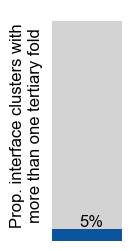

In [9]:
cath_diverse_pct = 721 / (721 + 13004)

fig, ax = plt.subplots(figsize=(1,3))
ax.spines.top.set_visible(False)
ax.spines.bottom.set_visible(False)
ax.spines.right.set_visible(False)
ax.spines.left.set_visible(False)
ax.bar(["CATH"], [cath_diverse_pct], 0.5, bottom=[0,0], color="#0b559f", label="Heterogeneous clusters")
ax.bar(["CATH"], [1-cath_diverse_pct], 0.5, bottom=[cath_diverse_pct], color="lightgray", label="Homogeneous clusters")
ax.text(-0.05, 0.065, "5%", fontsize=12)
ax.set_yticks([])
ax.set_xticks([])
ax.set_ylabel("Prop. interface clusters with\nmore than one tertiary fold", fontsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/cath_diversity_barplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/cath_diversity_barplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel b

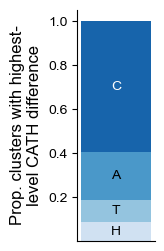

In [14]:
class_pct = 430 / 721
arch_pct = (586-430) / 721
topo_pct = (659-586) / 721
homo_pct = (721-659) / 721

fig, ax = plt.subplots(figsize=(1,3))
ax.spines.top.set_visible(False)
ax.spines.bottom.set_visible(True)
ax.spines.right.set_visible(False)
ax.spines.left.set_visible(True)
palette = sns.color_palette('Blues', n_colors=4)
ax.bar(["Top level"], [homo_pct], 0.5, bottom=[0], color=palette[0], label="Superfamily")
ax.bar(["Top level"], [topo_pct], 0.5, bottom=[homo_pct], color=palette[1], label=["Topology"])
ax.bar(["Top level"], [arch_pct], 0.5, bottom=[homo_pct+topo_pct], color=palette[2], label=["Architecture"])
ax.bar(["Top level"], [class_pct], 0.5, bottom=[homo_pct+topo_pct+arch_pct], color=palette[3], label=["Class"])
ax.text(0, homo_pct/2, "H", verticalalignment='center', horizontalalignment='center')
ax.text(0, (homo_pct + topo_pct/2), "T", verticalalignment='center', horizontalalignment='center')
ax.text(0, (homo_pct + topo_pct + arch_pct/2), "A", verticalalignment='center', horizontalalignment='center')
ax.text(0, (1-class_pct/2), "C", color='white', verticalalignment='center', horizontalalignment='center')
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks([])
ax.set_ylabel("Prop. clusters with highest-\nlevel CATH difference", fontsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/cath_hierarchy_barplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/cath_hierarchy_barplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel c

In [11]:
cluster_summary.loc[:, "cath_diverse"] = "NA"
cluster_summary.loc[cluster_summary["intcluster"].isin(all_same_cath_clusters_filtered), "cath_diverse"] = "CATH-Homogeneous"
cluster_summary.loc[cluster_summary["intcluster"].isin(diverse_cath_clusters_filtered), "cath_diverse"] = "CATH-Heterogeneous"

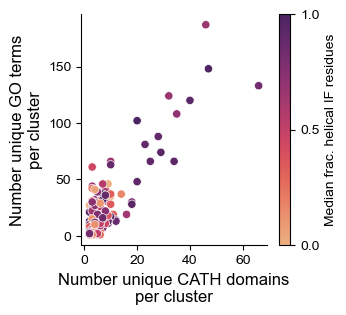

In [15]:
fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.scatterplot(data=cluster_summary[cluster_summary["cath_diverse"] == "CATH-Heterogeneous"], x="num_caths", y="num_gos", hue="median_helixfrac", palette="flare", ax=ax)
ax.set_xlabel("Number unique CATH domains\nper cluster", fontsize=12)
ax.set_ylabel("Number unique GO terms\nper cluster", fontsize=12)
ax.tick_params(axis='both', labelsize=10)

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
ax.get_legend().remove()
ax.figure.colorbar(sm, ticks=[0.0, 0.5, 1.0], label="Median frac. helical IF residues", ax=ax)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/numcath_numgo_scatterplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/numcath_numgo_scatterplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel d/e

In [8]:
# Example cluster chosen for helical interfaces: 36
# Example cluster chosen for beta-strand interfaces: 32423

In [8]:
pdb_clusters[((pdb_clusters["intcluster"] == 36) & (pdb_clusters["intrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
877715,9101358,B,5b83-assembly1,C,152521,122478,36,1,1,124,...,NaN,0.0,NaN,SIGNALING PROTEIN,X-RAY DIFFRACTION,2.694,Crystal structure of Optineurin UBAN in comple...,"FIP2,GLC1E,HIP7,HYPL,NRP,OPTN","FIP2,GLC1E,HIP7,HYPL,NRP,OPTN",NaN


In [9]:
combined_cath_diversity[combined_cath_diversity["intcluster"] == 36]

,intcluster,class_pair,arch_pair,topo_pair,homol_pair
0,36,3,5,6,17


In [10]:
combined_clusters[combined_clusters["intcluster"] == 36]["homol_pair"].unique()

array(['1.20.5.230-1.20.5.230', '1.20.5.350-1.20.5.350',
       '1.20.5.190-1.20.5.190', '1.10.442.10-4.10.51.10',
       '1.10.287.670-1.10.287.670', '1.20.5.730-1.20.5.730',
       '1.20.5.110-1.20.5.110', '1.20.5.340-1.20.5.340',
       '1.20.5.1000-1.20.5.1000', '1.20.5.990-1.20.5.990',
       '2.60.120.10-2.60.120.10', '1.20.5.1930-1.20.5.1930',
       '1.20.5.4090-1.20.5.4090', '1.20.58.1770-1.20.58.1770',
       '1.20.5.4880-1.20.5.4880', '1.20.5.1430-1.20.5.1430',
       '1.25.10.10-1.25.10.10'], dtype=object)

In [11]:
pdb_clusters[((pdb_clusters["intcluster"] == 36) & (pdb_clusters["intrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
877715,9101358,B,5b83-assembly1,C,152521,122478,36,1,1,124,...,NaN,0.0,NaN,SIGNALING PROTEIN,X-RAY DIFFRACTION,2.694,Crystal structure of Optineurin UBAN in comple...,"FIP2,GLC1E,HIP7,HYPL,NRP,OPTN","FIP2,GLC1E,HIP7,HYPL,NRP,OPTN",NaN


In [12]:
pdb_clusters[((pdb_clusters["intcluster"] == 36) & (pdb_clusters["cath_annot"] == "2.60.120.10-2.60.120.10"))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
429775,36972250,A,3dn7-assembly1,B,493181,128080,36,1,0,298,...,2.60.120.10-2.60.120.10,1.0,NaN,"structural genomics, unknown function",X-RAY DIFFRACTION,1.8,Cyclic nucleotide binding regulatory protein f...,NaN,NaN,NaN


In [13]:
pdb_clusters[((pdb_clusters["intcluster"] == 36) & (pdb_clusters["cath_annot"] == "1.10.442.10-4.10.51.10") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
209603,215756031,Q,1v54-assembly1,X,2439242,76801,36,1,0,197,...,1.10.442.10-4.10.51.10,1.0,NaN,OXIDOREDUCTASE,X-RAY DIFFRACTION,1.8,Bovine heart cytochrome c oxidase at the fully...,"COX4,COX4I1",COX7B,GO:0006123


In [14]:
pdb_clusters[((pdb_clusters["intcluster"] == 36) & (pdb_clusters["cath_annot"] == "1.20.5.350-1.20.5.350") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
83863,76464039,E,1j1d-assembly2,F,1123892,100979,36,1,0,195,...,1.20.5.350-1.20.5.350,1.0,NaN,CONTRACTILE PROTEIN,X-RAY DIFFRACTION,2.61,Crystal structure of the 46kDa domain of human...,TNNT2,"TNNC1,TNNI3",GO:0055010


In [15]:
print(cluster_summary[cluster_summary["intcluster"] == 36].iloc[:,0:20])

    cluster_size  first_date  cluster_qtm  pct_intraspecies  num_species  \
36           443  19940131.0        0.531             0.971           23   

    pct_protprot  pct_protpep  pct_peppep   top_protpepcat  pct_disdis  \
36           1.0          NaN         NaN  Protein-protein       0.014   

    pct_disord  pct_ordord   top_discat  pct_coiledcoil  pdb_ab  num_pfams  \
36       0.002       0.953  Order-order           0.169     0.0         26   

                                             top_pfam  pct_top_pfam  \
36  Cytochrome C oxidase chain VIIB_Cytochrome c o...      0.397291   

    num_caths                top_cath  
36         18  1.10.442.10-4.10.51.10  


In [16]:
tax_ids = pd.Series([str(x) for x in pdb_clusters[pdb_clusters["intcluster"] == 36]["tax_id_0"]])
tax_ids.value_counts()

9913.0       157
28285.0       60
930945.0      53
9606.0        42
10871.0       29
9823.0        22
nan           13
2285.0        13
10090.0       12
562.0          8
10116.0        6
1223261.0      6
209285.0       4
4932.0         3
10756.0        3
223283.0       2
9940.0         2
1423.0         2
2336.0         1
83332.0        1
269798.0       1
103796.0       1
7227.0         1
103690.0       1
Name: count, dtype: int64

In [17]:
helical_cluster_uniprots_Bt = list(pdb_clusters[((pdb_clusters["intcluster"] == 36) | (pdb_clusters["tax_id_0"] == 9913))]["uniprot_ids"])
helical_cluster_uniprots_Bt = [y for x in helical_cluster_uniprots_Bt if isinstance(x, str) for y in x.split("-")]
helical_cluster_uniprots_Bt = list(set(helical_cluster_uniprots_Bt))
with open("/Users/stromjoe/Documents/helical_cluster_uniprots_Bt.txt", "w+") as f:
    f.write(",".join(helical_cluster_uniprots_Bt))

helical_cluster_uniprots_Hs = list(pdb_clusters[((pdb_clusters["intcluster"] == 36) | (pdb_clusters["tax_id_0"] == 9606))]["uniprot_ids"])
helical_cluster_uniprots_Hs = [y for x in helical_cluster_uniprots_Hs if isinstance(x, str) for y in x.split("-")]
helical_cluster_uniprots_Hs = list(set(helical_cluster_uniprots_Hs))
with open("/Users/stromjoe/Documents/helical_cluster_uniprots_Hs.txt", "w+") as f:
    f.write(",".join(helical_cluster_uniprots_Hs))

In [18]:
pdb_clusters[((pdb_clusters["intcluster"] == 32423) & (pdb_clusters["intrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
731705,69326506,C,4hsv-assembly1,D,983331,176714,32423,1,1,128,...,2.40.50.40-2.40.50.40,1.0,NaN,ANTITUMOR PROTEIN,X-RAY DIFFRACTION,2.083,Crystal Structure of CXCL4L1,"CXCL4V1,PF4V1,SCYB4V1","CXCL4V1,PF4V1,SCYB4V1",GO:0030593


In [19]:
combined_cath_diversity[combined_cath_diversity["intcluster"] == 32423]

,intcluster,class_pair,arch_pair,topo_pair,homol_pair
310,32423,2,6,9,11


In [20]:
combined_cath_diversity[combined_cath_diversity["intcluster"] == 32423]

,intcluster,class_pair,arch_pair,topo_pair,homol_pair
310,32423,2,6,9,11


In [21]:
combined_clusters[combined_clusters["intcluster"] == 32423]["homol_pair"].unique()

array(['2.40.50.40-2.40.50.40', '3.30.70.1150-3.30.70.1150',
       '2.20.70.140-2.20.70.140', '3.30.70.1490-3.30.70.1490',
       '3.10.20.10-3.10.20.10', '3.30.56.30-3.30.56.30',
       '2.60.40.2020-2.60.40.2020', '2.60.40.4110-2.60.40.4110',
       '2.20.220.20-2.20.220.20', '2.20.230.10-2.20.230.10',
       '3.20.100.10-3.20.100.10'], dtype=object)

In [22]:
pdb_clusters[((pdb_clusters["intcluster"] == 32423) & (pdb_clusters["cath_annot"] == "2.20.230.10-2.20.230.10") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
721731,57420757,B,4fzq-assembly1,E,800164,59302,32423,1,0,158,...,2.20.230.10-2.20.230.10,1.0,NaN,IMMUNE SYSTEM,X-RAY DIFFRACTION,2.5,Crystal structure of HP0197-G5,NaN,NaN,NaN
721732,57420759,C,4fzq-assembly1,D,800165,59303,32423,1,0,159,...,2.20.230.10-2.20.230.10,1.0,NaN,IMMUNE SYSTEM,X-RAY DIFFRACTION,2.5,Crystal structure of HP0197-G5,NaN,NaN,NaN


In [23]:
pdb_clusters[((pdb_clusters["intcluster"] == 32423) & (pdb_clusters["cath_annot"] == "2.60.40.4110-2.60.40.4110") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
627424,200647396,A-2,3sb3-assembly1,A-4,2174790,58935,32423,1,0,206,...,2.60.40.4110-2.60.40.4110,1.0,NaN,"Structural Genomics, Unknown Function",X-RAY DIFFRACTION,1.83,Crystal structure of an apag protein (PA1934) ...,PA1934,PA1934,NaN


In [24]:
pdb_clusters[((pdb_clusters["intcluster"] == 32423) & (pdb_clusters["cath_annot"] == "3.20.100.10-3.20.100.10") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
770577,163277937,A,4pn1-assembly3,C,1839008,107634,32423,1,0,519,...,3.20.100.10-3.20.100.10,1.0,NaN,HYDROLASE/TRANSCRIPTION REGULATOR,X-RAY DIFFRACTION,2.803,Structure of S. pombe Pct1 RNA triphosphatase ...,"SPAC644.04,pct1","SPAC644.04,pct1",GO:0006370


In [25]:
pdb_clusters[((pdb_clusters["intcluster"] == 32423) & (pdb_clusters["cath_annot"] == "3.10.20.10-3.10.20.10") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
325932,90317727,A,2kwd-assembly1,C,1336999,162762,32423,1,0,116,...,3.10.20.10-3.10.20.10,1.0,NaN,IMMUNE SYSTEM,SOLID-STATE NMR,NaN,Supramolecular Protein Structure Determination...,spg,spg,GO:0019864


In [26]:
pdb_clusters[((pdb_clusters["intcluster"] == 32423) & (pdb_clusters["cath_annot"] == "3.30.70.1150-3.30.70.1150") & (pdb_clusters["dimerrep"] == 1))]

,old_complex_id,chain_id_0,pdb_id,chain_id_1,new_complex_id,dimercluster,intcluster,dimerrep,intrep,dimer_len,...,cath_annot,cath_is_pair,antibody,pdb_keyword,pdb_expt_method,pdb_resolution,pdb_title,gene_names_0,gene_names_1,go_cat
157012,170589356,A,1q5v-assembly1,C,1896179,98929,32423,1,0,234,...,3.30.70.1150-3.30.70.1150,1.0,NaN,TRANSCRIPTION,X-RAY DIFFRACTION,2.30,Apo-NikR,"JW3446,b3481,nikR,yhhG","JW3446,b3481,nikR,yhhG",GO:0010045
338992,151761652,A,2nzc-assembly1,C,1676754,22567,32423,1,0,164,...,3.30.70.1150-3.30.70.1150,1.0,NaN,Structural Genomics/Unknown Function,X-RAY DIFFRACTION,1.95,The structure of uncharacterized protein TM126...,TM_1266,TM_1266,NaN
415903,9774631,B,3bku-assembly1,D,182142,70631,32423,1,0,152,...,3.30.70.1150-3.30.70.1150,1.0,NaN,METAL BINDING PROTEIN,X-RAY DIFFRACTION,2.10,Apo C-terminal Domain of NikR,"JW3446,b3481,nikR,yhhG","JW3446,b3481,nikR,yhhG",GO:0010045


In [27]:
print(cluster_summary[cluster_summary["intcluster"] == 32423].iloc[:,20:])

       pct_top_cath  num_gos      top_go  pct_top_go  median_ifsize  \
32423      0.046133     37.0  GO:0006412    0.466757           37.0   

       min_ifsize  max_ifsize  median_helixfrac  median_betafrac  \
32423        24.0        73.0             0.162            0.513   

       median_bendturnfrac  median_unassignfrac  num_keywords top_keyword  \
32423                0.162                0.154            46    RIBOSOME   

       pct_top_keyword  count  num_exptmethods       top_exptmethod  \
32423         0.686567    737                4  ELECTRON MICROSCOPY   

       pct_top_exptmethod  median_resolution  intcluster  
32423            0.666214               3.12       32423  


In [28]:
tax_ids = pd.Series([str(x) for x in pdb_clusters[pdb_clusters["intcluster"] == 32423]["tax_id_0"]])
tax_ids.value_counts()

9606.0      212
559292.0    109
4932.0      102
9986.0      102
5476.0       18
           ... 
5722.0        1
3702.0        1
5693.0        1
6039.0        1
5811.0        1
Name: count, Length: 61, dtype: int64

In [ ]:
# Write lists of Uniprot IDs in the structurally-diverse clusters for functional enrichment analysis in enrichGO_humanppi_nohit.R
strand_cluster_uniprots_Hs = list(pdb_clusters[((pdb_clusters["intcluster"] == 32423) | (pdb_clusters["tax_id_0"] == 9606))]["uniprot_ids"])
strand_cluster_uniprots_Hs = [y for x in strand_cluster_uniprots_Hs if isinstance(x, str) for y in x.split("-")]
strand_cluster_uniprots_Hs = list(set(strand_cluster_uniprots_Hs))
with open("/Users/stromjoe/Documents/strand_cluster_uniprots_Hs.txt", "w+") as f:
    f.write(",".join(strand_cluster_uniprots_Hs))

strand_cluster_uniprots_Sc = list(pdb_clusters[((pdb_clusters["intcluster"] == 32423) | (pdb_clusters["tax_id_0"] == 559292))]["uniprot_ids"])
strand_cluster_uniprots_Sc = [y for x in strand_cluster_uniprots_Sc if isinstance(x, str) for y in x.split("-")]
strand_cluster_uniprots_Sc = list(set(strand_cluster_uniprots_Sc))
with open("/Users/stromjoe/Documents/strand_cluster_uniprots_Sc.txt", "w+") as f:
    f.write(",".join(strand_cluster_uniprots_Sc))

## Panel g

In [ ]:
old_cluster_reps = list(set(cluster_lca[cluster_lca["lca_id"] == 131567]["rep"]))
old_cluster_reps = [int(x.split("DI")[0]) for x in old_cluster_reps]
old_cluster_ids = list(set(pdb_clusters[pdb_clusters["old_complex_id"].isin(old_cluster_reps)]["intcluster"]))
print(len(old_cluster_ids))

human_cluster_reps = list(set(cluster_lca[cluster_lca["lca_id"] == 9606]["rep"]))
human_cluster_reps = [int(x.split("DI")[0]) for x in human_cluster_reps]
human_cluster_ids = list(set(pdb_clusters[pdb_clusters["old_complex_id"].isin(human_cluster_reps)]["intcluster"]))
print(len(human_cluster_ids))

In [ ]:
old_clusters = cluster_summary[cluster_summary["intcluster"].isin(old_cluster_ids)]
print(old_clusters["top_discat"].value_counts())

human_clusters = cluster_summary[cluster_summary["intcluster"].isin(human_cluster_ids)]
print(human_clusters["top_discat"].value_counts())

In [ ]:
old_cluster_dispct = (56 + 304) / (56 + 304 + 2311)
human_cluster_dispct = (1823 + 460) / (1823 + 460 + 8670)

fig, ax = plt.subplots(figsize=(3,3))
ax.spines.top.set_visible(False)
ax.spines.bottom.set_visible(False)
ax.spines.right.set_visible(False)
ax.spines.left.set_visible(False)
ax.bar([0,1], [old_cluster_dispct, human_cluster_dispct], color="#0b559f", bottom=[0,0])
ax.bar([0,1], [1-old_cluster_dispct, 1-human_cluster_dispct], color="lightgray", bottom=[old_cluster_dispct, human_cluster_dispct])
ax.text(0, old_cluster_dispct+0.02, "13%", fontsize=12, horizontalalignment='center')
ax.text(1, human_cluster_dispct+0.02, "21%", fontsize=12, horizontalalignment='center')
ax.hlines(y=1.02, xmin=0, xmax=1, linestyle='solid', color='black')
ax.text(x=0.5, y=1.025, s="****", color="black", fontsize=10, horizontalalignment='center')
ax.set_yticks([])
ax.set_xticks([0,1])
ax.set_xticklabels(["Old clusters", "New clusters"])
ax.set_ylabel("Prop. clusters with disorder-\nmediated interfaces", fontsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/oldvsnew_disorder_barplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/oldvsnew_disorder_barplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

In [ ]:
print(old_cluster_dispct, human_cluster_dispct)
print(scipy.stats.fisher_exact([[(56 + 304),2311],[(1823 + 460),8670]]))

## Panel S3a

In [ ]:
old_cluster_ifs = pdb_clusters[pdb_clusters["intcluster"].isin(old_cluster_ids)]
human_cluster_ifs = pdb_clusters[pdb_clusters["intcluster"].isin(human_cluster_ids)]

old_cluster_ifs.dropna(subset=["go_cat"], axis=0, inplace=True)
human_cluster_ifs.dropna(subset=["go_cat"], axis=0, inplace=True)

old_cluster_filter_goterms = ",".join(list(old_cluster_ifs.go_cat))
human_cluster_goterms = ",".join(list(human_cluster_ifs.go_cat))

old_cluster_filter_goterms = old_cluster_filter_goterms.split(",")
human_cluster_goterms = human_cluster_goterms.split(",")

print(len(old_cluster_filter_goterms))
print(len(set(old_cluster_filter_goterms)))
print(len(human_cluster_goterms))
print(len(set(human_cluster_goterms)))

In [ ]:
old_cluster_filter_goterms_df = pd.Series(old_cluster_filter_goterms).value_counts().to_frame()
old_cluster_filter_goterms_df.columns = ["oldclust_count"]
human_cluster_goterms_df = pd.Series(human_cluster_goterms).value_counts().to_frame()
human_cluster_goterms_df.columns = ["humanclust_count"]

goterms_df = pd.merge(old_cluster_filter_goterms_df, human_cluster_goterms_df, left_index=True, right_index=True, how="outer")

In [ ]:
print(len(goterms_df[goterms_df["oldclust_count"].isna()]))
print(len(goterms_df[goterms_df["humanclust_count"].isna()]))
print(len(goterms_df) - len(goterms_df[goterms_df["oldclust_count"].isna()]) - len(goterms_df[goterms_df["humanclust_count"].isna()]))

In [ ]:
oldclust_total = goterms_df["oldclust_count"].sum()
humanclust_total = goterms_df["humanclust_count"].sum()

goterms_df.fillna(1, inplace=True)

goterms_df["oldclust_freq"] = goterms_df["oldclust_count"] / oldclust_total
goterms_df["humanclust_freq"] = goterms_df["humanclust_count"] / humanclust_total
goterms_df["freq_ratio"] = goterms_df["humanclust_freq"] / goterms_df["oldclust_freq"]
goterms_df["freq_diff"] = goterms_df["humanclust_freq"] - goterms_df["oldclust_freq"]
goterms_df["log_freq_ratio"] = [np.log2(x) for x in goterms_df["freq_ratio"]]

def get_chi2_pvalue(x):
    x_human = x["humanclust_count"]
    notx_human = humanclust_total - x_human
    x_old = x["oldclust_count"]
    notx_old = oldclust_total - x_old
    contingency_table = [[x_human, notx_human], [x_old, notx_old]]
    return scipy.stats.chi2_contingency(contingency_table).pvalue

goterms_df["pvalue"] = goterms_df.apply(lambda x: get_chi2_pvalue(x), axis=1)
goterms_df["adj_pvalue"] = scipy.stats.false_discovery_control(goterms_df["pvalue"], axis=0, method='bh')
goterms_df["adj_pvalue"] = [np.nan if x == 0 else x for x in goterms_df["adj_pvalue"]]
min_pvalue = goterms_df["adj_pvalue"].min()
goterms_df["adj_pvalue"] = [min_pvalue if x == np.nan else x for x in goterms_df["adj_pvalue"]]
goterms_df["log_pvalue"] = [-np.log10(x) for x in goterms_df["adj_pvalue"]]

In [ ]:
goterms_df.sort_values(by=["log_pvalue","log_freq_ratio"], ascending=[False,False])[0:20]

In [ ]:
goterms_df.sort_values(by="log_freq_ratio", ascending=True)[0:20]

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.scatterplot(data=goterms_df, x="log_freq_ratio", y="log_pvalue", ax=ax)
ax.set_xticks([np.log2(0.0001), np.log2(0.001), np.log2(0.01), np.log2(0.1), np.log2(1), np.log2(10), np.log2(100)])
ax.set_xticklabels(["0.0001","0.001", "0.01", "0.1", "1", "10", "100"])
ax.set_xlabel("Fold enrichment of GO term in new cluster vs. old cluster", fontsize=12)
ax.text(x=-10.204683-0.5, y=258.945663, s="1", fontsize=10, verticalalignment='center', horizontalalignment='center') #GO:0006826; -10.204683,258.945663
ax.text(x=-9.749890-0.5, y=188.029301, s="2", fontsize=10, verticalalignment='center', horizontalalignment='center') #GO:0015986; -9.749890,188.029301
ax.text(x=-8.745832-0.5, y=93.017814, s="3", fontsize=10, verticalalignment='center', horizontalalignment='center') #GO:0009374; -8.745832,93.017814
ax.text(x=5.007684, y=287.743258+12, s="4", fontsize=10, verticalalignment='center', horizontalalignment='center') #GO:0001501; 5.007684,287.743258
ax.text(x=9.346980, y=277.877430+12, s="5", fontsize=10, verticalalignment='center', horizontalalignment='center') #GO:0002224; 9.346980,277.877430
ax.text(x=10.458011, y=302.143018+12, s="6", fontsize=10, verticalalignment='center', horizontalalignment='center') #GO:0002331; 10.458011,302.143018
ax.set_ylabel("-log10(FDR-adjusted p-value)", fontsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/goenrichment_scatterplot.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/goenrichment_scatterplot.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')